# 03 — Modelagem e avaliação

Este notebook continua como centro principal de discussão, justificativa metodológica e leitura crítica da modelagem. Em paralelo, o arquivo `src/pipeline.py` deixou de ser apenas placeholder e passou a concentrar uma trilha complementar por CLI, baseada em `Pipeline` e `ColumnTransformer` do scikit-learn, para organizar cenários e execuções reproduzíveis sem substituir a narrativa do notebook nesta branch.


## 1. Imports e configuração


### Justificativa das configurações
- `RANDOM_STATE=42`: garante reprodutibilidade.
- `CV_SPLITS=3`: reduz custo computacional mantendo validação robusta para o volume de dados.
- `MIN_RECALL_THRESHOLD=0.80`: prioriza sensibilidade clínica para reduzir falso negativo de prematuridade.

### Decisão formal do Bloco 2
- **Mantido `CV_SPLITS=3`** por viabilidade computacional nesta base (700k+ registros).
- Trade-off aceito: menor estabilidade estatística que 5-fold, com execução significativamente mais rápida para cumprir prazo.


In [1]:
import gc
import json
import os
import pickle
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.base import clone
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
    f1_score,
    fbeta_score,
    make_scorer,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import StratifiedKFold, train_test_split

from utils import load_parquet_safe

SRC_DIR = Path("../src").resolve()
if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))

from pipeline import (
    apply_scenario,
    build_fit_kwargs,
    build_model_search_configs,
    build_randomized_search,
    build_scenario_catalog,
    build_scenario_model_grid,
    MODEL_DISPLAY_NAMES,
)

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("deep")

RANDOM_STATE = 42
N_JOBS = -1
CV_SPLITS = 3  # Ajuste enxuto para manter tempo de execução viável
MIN_RECALL_THRESHOLD = 0.80
VALIDATION_SIZE_FOR_THRESHOLD = 0.20
BOOTSTRAP_ROUNDS = 300

## 2. Carga dos artefatos do preprocessing


In [2]:
# Entradas geradas no 02_preprocessing.ipynb
X_train = load_parquet_safe("../data/X_train.parquet", "02_preprocessing.ipynb")
X_test = load_parquet_safe("../data/X_test.parquet", "02_preprocessing.ipynb")
y_train = load_parquet_safe("../data/y_train.parquet", "02_preprocessing.ipynb").iloc[:, 0]
y_test = load_parquet_safe("../data/y_test.parquet", "02_preprocessing.ipynb").iloc[:, 0]

# Pastas de saída
FIGURES_DIR = Path("../results/figures")
METRICS_DIR = Path("../results/metrics")
ARTIFACTS_DIR = Path("../results/artifacts")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
METRICS_DIR.mkdir(parents=True, exist_ok=True)
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

ACTIVE_SCENARIO = "A"
print("Cenario inicial de referência:", ACTIVE_SCENARIO)


X_train: (552344, 49)
X_test: (138087, 49)
y_train: (552344,)
y_test: (138087,)
Cenario inicial de referência: A


## 3. Checagens de consistência


In [3]:
display(pd.DataFrame({
    "dataset": ["X_train", "X_test", "y_train", "y_test"],
    "rows": [len(X_train), len(X_test), len(y_train), len(y_test)],
    "cols": [X_train.shape[1], X_test.shape[1], 1, 1],
    "has_null": [X_train.isna().any().any(), X_test.isna().any().any(), y_train.isna().any(), y_test.isna().any()],
}))

train_dist = y_train.value_counts(normalize=True).rename("proporcao_treino").sort_index()
test_dist = y_test.value_counts(normalize=True).rename("proporcao_teste").sort_index()
display(pd.concat([train_dist, test_dist], axis=1))


,dataset,rows,cols,has_null
0,X_train,552344,49,False
1,X_test,138087,49,False
2,y_train,552344,1,False
3,y_test,138087,1,False


,proporcao_treino,proporcao_teste
PREMATURO,,
0,0.897987,0.897992
1,0.102013,0.102008


## 3.1 Cenários de features

Três cenários testam **como representar** as mesmas informações clínicas:

| Cenário | Features | Lógica |
|---|---|---|
| **A** — dummies + bools | 42 | Tudo em binário. Variáveis contínuas trocadas por flags/faixas |
| **B** — ordinal + contínuo | 29 | Tudo em número. Dummies trocadas por ordinais; bools trocados por contínuas |
| **C** — todos | 49 | União de A e B — ambas as representações simultâneas |

Premissas comuns a todos:
- Dados já normalizados (StandardScaler no preprocessing, mean=0 std=1)
- Zero nulos em qualquer cenário
- `QTDPARTNOR` e `QTDPARTCES` ficam contínuas nos três (sem bool equivalente)

## 4. Protocolo de avaliação


In [4]:
# Descrição detalhada dos cenários
_SCENARIO_PAIRS = [
    ("Escolaridade da mãe",   "ESCMAE2010_ORDINAL",  "ESCMAE2010_* dummies"),
    ("Pré-natal (Kotelchuck)","KOTELCHUCK_ORDINAL",  "KOTELCHUCK_* dummies"),
    ("Idade da mãe",          "IDADEMAE",             "FAIXAETAMAE_* dummies"),
    ("Pré-natal tardio",      "MESPRENAT",            "PNTARDIO (bool)"),
    ("Perda fetal",           "QTDFILMORT",           "HISTPERDAFETAL (bool)"),
    ("Paridade",              "QTDFILVIVO + QTDGESTANT", "PRIMIPARA (bool)"),
]

rows = []
for label, continua, dummy in _SCENARIO_PAIRS:
    rows.append({
        "Informação clínica": label,
        "A  (dummies+bools)": f"✓ {dummy}",
        "B  (ordinal+contínuo)": f"✓ {continua}",
        "C  (todos)": "✓ ambos",
    })

display(
    pd.DataFrame(rows).set_index("Informação clínica")
    .style.set_caption("Mapeamento de features por cenário")
    .set_properties(**{"text-align": "left"})
)

# Saúde dos dados por cenário
health = []
for sc in ["A", "B", "C"]:
    X = apply_scenario(X_train, sc)
    nulls = int(X.isna().sum().sum())
    scaled = all(round(X[c].mean(), 1) == 0.0 for c in X.select_dtypes("number").columns)
    outliers = [c for c in X.select_dtypes("number").columns if X[c].abs().max() > 10]
    health.append({
        "Cenário": sc,
        "Features": X.shape[1],
        "Nulos": nulls,
        "Normalizado": "✓" if scaled else "✗",
        "Colunas com outliers extremos (>10σ)": len(outliers),
    })

display(pd.DataFrame(health).set_index("Cenário"))

,A (dummies+bools),B (ordinal+contínuo),C (todos)
Informação clínica,,,
Escolaridade da mãe,✓ ESCMAE2010_* dummies,✓ ESCMAE2010_ORDINAL,✓ ambos
Pré-natal (Kotelchuck),✓ KOTELCHUCK_* dummies,✓ KOTELCHUCK_ORDINAL,✓ ambos
Idade da mãe,✓ FAIXAETAMAE_* dummies,✓ IDADEMAE,✓ ambos
Pré-natal tardio,✓ PNTARDIO (bool),✓ MESPRENAT,✓ ambos
Perda fetal,✓ HISTPERDAFETAL (bool),✓ QTDFILMORT,✓ ambos
Paridade,✓ PRIMIPARA (bool),✓ QTDFILVIVO + QTDGESTANT,✓ ambos


,Features,Nulos,Normalizado,Colunas com outliers extremos (>10σ)
Cenário,,,,
A,42,0,✓,12
B,29,0,✓,11
C,49,0,✓,15


### Por que este protocolo de métricas?
- Em saúde, perder casos positivos (falso negativo) é mais crítico; por isso `Recall` e `F2` são métricas centrais.
- `F2` dá mais peso ao recall do que o `F1`.
- `ROC-AUC` e `Average Precision` complementam a leitura global de discriminação e performance em classe desbalanceada.


In [5]:
cv = StratifiedKFold(n_splits=CV_SPLITS, shuffle=True, random_state=RANDOM_STATE)

scoring = {
    "recall": "recall",
    "f2": make_scorer(fbeta_score, beta=2),
    "f1": "f1",
    "precision": "precision",
    "roc_auc": "roc_auc",
    "average_precision": "average_precision",
    "accuracy": "accuracy",
}


def compute_binary_metrics(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return {
        "threshold": float(threshold),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f2": fbeta_score(y_true, y_pred, beta=2, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "accuracy": accuracy_score(y_true, y_pred),
        "roc_auc": roc_auc_score(y_true, y_prob),
        "average_precision": average_precision_score(y_true, y_prob),
        "brier": brier_score_loss(y_true, y_prob),
        "tp": int(tp),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
    }


def threshold_curve(y_true, y_prob, min_recall=0.80):
    thresholds = np.linspace(0.05, 0.95, 91)
    rows = []
    for th in thresholds:
        m = compute_binary_metrics(y_true, y_prob, threshold=th)
        m["meets_min_recall"] = m["recall"] >= min_recall
        rows.append(m)

    df_curve = pd.DataFrame(rows)

    valid = df_curve[df_curve["meets_min_recall"]]
    if len(valid) > 0:
        # F2 prioriza recall (peso 2x) enquanto considera precisão — correto para triagem clínica
        best_idx = valid["f2"].idxmax()
    else:
        best_idx = df_curve["f2"].idxmax()

    best_row = df_curve.loc[best_idx].to_dict()
    return df_curve, best_row


def bootstrap_ci(y_true, y_prob, threshold, rounds=300, seed=42):
    rng = np.random.default_rng(seed)
    tracked_metrics = ["roc_auc", "average_precision", "precision", "recall", "f2", "brier"]
    values = {metric: [] for metric in tracked_metrics}

    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    n = len(y_true)

    for _ in range(rounds):
        idx = rng.integers(0, n, n)
        y_boot = y_true[idx]
        y_prob_boot = y_prob[idx]
        if len(np.unique(y_boot)) < 2:
            continue
        metrics = compute_binary_metrics(y_boot, y_prob_boot, threshold=threshold)
        for metric in tracked_metrics:
            values[metric].append(metrics[metric])

    ci = {}
    for metric, metric_values in values.items():
        if len(metric_values) == 0:
            ci[metric] = {"low": None, "high": None}
            continue
        low, high = np.percentile(metric_values, [2.5, 97.5])
        ci[metric] = {"low": float(low), "high": float(high)}
    return ci


def write_json(data, output_path):
    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    with output_path.open("w", encoding="utf-8") as f:
        json.dump(data, f, ensure_ascii=False, indent=2)


## 5. Modelos e espaços de busca (tuning enxuto)

A definição das combinações cenário-modelo e dos espaços de busca passa a reaproveitar helpers de `src/pipeline.py`. A implementação executável continua discutida aqui no notebook, mas a importação evita duplicar estruturas de configuração e reduz divergência entre a trilha de notebook e a trilha por CLI.


### Justificativa dos modelos escolhidos
- `LogReg`: baseline linear e altamente interpretável.
- `RandomForest`: baseline ensemble robusto e útil para importância de variáveis.
- `HistGradientBoosting`: candidato de melhor performance em dados tabulares grandes, usando `sample_weight=balanced` para manter a comparação coerente com o desbalanceamento do alvo.

### Justificativa do tuning enxuto
- `RandomizedSearchCV` com espaço curto acelera iteração sem abrir mão de comparação justa entre modelos.


In [6]:
models = build_model_search_configs(random_state=RANDOM_STATE, n_jobs=N_JOBS)

scenario_catalog_df = pd.DataFrame(build_scenario_catalog(["A", "B", "C"]))
display(scenario_catalog_df)

SCENARIOS_TO_RUN = ["A", "B", "C"]
MODELS_TO_RUN = ["logreg", "random_forest", "histgb"]

scenario_model_grid = pd.DataFrame(
    build_scenario_model_grid(
        scenarios=SCENARIOS_TO_RUN,
        models=MODELS_TO_RUN,
    )
)
scenario_model_grid["model_display"] = scenario_model_grid["model"].map(MODEL_DISPLAY_NAMES)
display(scenario_model_grid[["scenario", "model_display"]])

search_results = {}

,scenario,description
0,A,dummies + bools
1,B,ordinal + continuo
2,C,todos


,scenario,model_display
0,A,LogisticRegression
1,A,RandomForest
2,A,HistGradientBoosting + sample_weight
3,B,LogisticRegression
4,B,RandomForest
5,B,HistGradientBoosting + sample_weight
6,C,LogisticRegression
7,C,RandomForest
8,C,HistGradientBoosting + sample_weight


## 6. Treino com RandomizedSearchCV e avaliação em teste (threshold padrão)


In [7]:
for scenario in SCENARIOS_TO_RUN:
    X_train_modeling = apply_scenario(X_train, scenario)
    X_test_modeling = apply_scenario(X_test, scenario)

    for model_name, cfg in models.items():
        pipeline_model_name = cfg.get("pipeline_model_name")
        if pipeline_model_name is not None and pipeline_model_name not in MODELS_TO_RUN:
            continue

        print(f"\nTreinando: cenário={scenario} | modelo={model_name}")

        search = build_randomized_search(
            estimator=cfg["estimator"],
            param_distributions=cfg["param_distributions"],
            scoring=scoring,
            cv=cv,
            n_iter=cfg["n_iter"],
            random_state=RANDOM_STATE,
            n_jobs=N_JOBS,
            refit="average_precision",
        )

        fit_kwargs = build_fit_kwargs(
            y_train,
            use_balanced_sample_weight=cfg.get("use_balanced_sample_weight", False),
        )

        search.fit(X_train_modeling, y_train, **fit_kwargs)
        best_estimator = search.best_estimator_

        y_test_prob = best_estimator.predict_proba(X_test_modeling)[:, 1]
        test_metrics_default = compute_binary_metrics(y_test, y_test_prob, threshold=0.5)

        result_key = f"{scenario}__{model_name}"
        search_results[result_key] = {
            "scenario": scenario,
            "model": model_name,
            "best_estimator": best_estimator,
            "best_params": search.best_params_,
            "cv_best_ap": search.best_score_,
            "cv_recall_mean": search.cv_results_["mean_test_recall"][search.best_index_],
            "cv_recall_std": search.cv_results_["std_test_recall"][search.best_index_],
            "cv_f2_mean": search.cv_results_["mean_test_f2"][search.best_index_],
            "cv_f2_std": search.cv_results_["std_test_f2"][search.best_index_],
            "cv_f1_mean": search.cv_results_["mean_test_f1"][search.best_index_],
            "cv_precision_mean": search.cv_results_["mean_test_precision"][search.best_index_],
            "cv_roc_auc_mean": search.cv_results_["mean_test_roc_auc"][search.best_index_],
            "cv_ap_mean": search.cv_results_["mean_test_average_precision"][search.best_index_],
            "cv_accuracy_mean": search.cv_results_["mean_test_accuracy"][search.best_index_],
            "cv_accuracy_std": search.cv_results_["std_test_accuracy"][search.best_index_],
            "imbalance_strategy": cfg["imbalance_strategy"],
            "use_balanced_sample_weight": cfg.get("use_balanced_sample_weight", False),
            "test_metrics_default": test_metrics_default,
            "n_features": int(X_train_modeling.shape[1]),
        }

        del fit_kwargs, search, best_estimator, y_test_prob, test_metrics_default
        gc.collect()

print("\nTreino/tuning concluído para todos os cenários e modelos.")



Treinando: cenário=A | modelo=LogReg
Fitting 3 folds for each of 10 candidates, totalling 30 fits

Treinando: cenário=A | modelo=RandomForest
Fitting 3 folds for each of 10 candidates, totalling 30 fits

Treinando: cenário=A | modelo=HistGB
Fitting 3 folds for each of 10 candidates, totalling 30 fits

Treinando: cenário=B | modelo=LogReg
Fitting 3 folds for each of 10 candidates, totalling 30 fits

Treinando: cenário=B | modelo=RandomForest
Fitting 3 folds for each of 10 candidates, totalling 30 fits

Treinando: cenário=B | modelo=HistGB
Fitting 3 folds for each of 10 candidates, totalling 30 fits

Treinando: cenário=C | modelo=LogReg
Fitting 3 folds for each of 10 candidates, totalling 30 fits

Treinando: cenário=C | modelo=RandomForest
Fitting 3 folds for each of 10 candidates, totalling 30 fits

Treinando: cenário=C | modelo=HistGB
Fitting 3 folds for each of 10 candidates, totalling 30 fits

Treino/tuning concluído para todos os cenários e modelos.


## 7. Tabela consolidada: CV + teste


In [8]:
comparison_rows = []
for _, result in search_results.items():
    row = {
        "scenario": result["scenario"],
        "model": result["model"],
        "n_features": result["n_features"],
        "imbalance_strategy": result["imbalance_strategy"],
        "selection_metric": "max_cv_average_precision",
        "cv_recall_mean": result["cv_recall_mean"],
        "cv_recall_std": result["cv_recall_std"],
        "cv_f2_mean": result["cv_f2_mean"],
        "cv_f2_std": result["cv_f2_std"],
        "cv_f1_mean": result["cv_f1_mean"],
        "cv_precision_mean": result["cv_precision_mean"],
        "cv_roc_auc_mean": result["cv_roc_auc_mean"],
        "cv_average_precision_mean": result["cv_ap_mean"],
        "cv_accuracy_mean": result["cv_accuracy_mean"],
        "cv_accuracy_std": result["cv_accuracy_std"],
        "test_recall_default": result["test_metrics_default"]["recall"],
        "test_f2_default": result["test_metrics_default"]["f2"],
        "test_f1_default": result["test_metrics_default"]["f1"],
        "test_precision_default": result["test_metrics_default"]["precision"],
        "test_accuracy_default": result["test_metrics_default"]["accuracy"],
        "test_roc_auc": result["test_metrics_default"]["roc_auc"],
        "test_average_precision": result["test_metrics_default"]["average_precision"],
        "best_params": str(result["best_params"]),
    }
    comparison_rows.append(row)

comparison_df = pd.DataFrame(comparison_rows)
comparison_df = comparison_df.sort_values("cv_average_precision_mean", ascending=False).reset_index(drop=True)

display(comparison_df)
comparison_df.to_csv(METRICS_DIR / "model_comparison_cv_test.csv", index=False)
print("Salvo:", METRICS_DIR / "model_comparison_cv_test.csv")


,scenario,model,n_features,imbalance_strategy,selection_metric,cv_recall_mean,cv_recall_std,cv_f2_mean,cv_f2_std,cv_f1_mean,...,cv_accuracy_mean,cv_accuracy_std,test_recall_default,test_f2_default,test_f1_default,test_precision_default,test_accuracy_default,test_roc_auc,test_average_precision,best_params
0,C,HistGB,49,sample_weight=balanced,max_cv_average_precision,0.494960,0.004269,0.519190,0.003805,0.560342,...,0.611658,0.001262,0.496024,0.358775,0.253543,0.170294,0.702065,0.653972,0.207702,"{'min_samples_leaf': 100, 'max_leaf_nodes': 31..."
1,B,HistGB,29,sample_weight=balanced,max_cv_average_precision,0.496912,0.001641,0.520811,0.001517,0.561306,...,0.611636,0.000897,0.498509,0.359796,0.253845,0.170276,0.701051,0.654026,0.207196,"{'min_samples_leaf': 100, 'max_leaf_nodes': 31..."
2,A,HistGB,42,sample_weight=balanced,max_cv_average_precision,0.473077,0.004773,0.500110,0.004294,0.547002,...,0.608245,0.001201,0.483175,0.355171,0.254169,0.172439,0.710740,0.650285,0.204698,"{'min_samples_leaf': 50, 'max_leaf_nodes': 63,..."
3,C,RandomForest,49,random_search(class_weight),max_cv_average_precision,0.458276,0.003328,0.345503,0.001660,0.252358,...,0.722997,0.001574,0.459747,0.344201,0.249966,0.171645,0.718561,0.641907,0.198504,"{'n_estimators': 200, 'min_samples_leaf': 4, '..."
4,B,RandomForest,29,random_search(class_weight),max_cv_average_precision,0.460476,0.005022,0.346234,0.002350,0.252338,...,0.721644,0.001781,0.462019,0.343982,0.248682,0.170126,0.715223,0.641602,0.198187,"{'n_estimators': 200, 'min_samples_leaf': 4, '..."
5,A,RandomForest,42,random_search(class_weight),max_cv_average_precision,0.454247,0.004720,0.342692,0.002107,0.250444,...,0.722631,0.001906,0.458469,0.341722,0.247272,0.169288,0.715266,0.638743,0.194359,"{'n_estimators': 200, 'min_samples_leaf': 4, '..."
6,C,LogReg,49,class_weight=balanced,max_cv_average_precision,0.468250,0.004364,0.344733,0.002050,0.247006,...,0.708770,0.001544,0.463155,0.340111,0.243197,0.164889,0.705953,0.634468,0.185382,"{'solver': 'liblinear', 'penalty': 'l1', 'C': ..."
7,A,LogReg,42,class_weight=balanced,max_cv_average_precision,0.464913,0.004398,0.342792,0.001927,0.245910,...,0.709131,0.002179,0.462019,0.340110,0.243668,0.165467,0.707424,0.631475,0.182194,"{'solver': 'lbfgs', 'penalty': 'l2', 'C': np.f..."
8,B,LogReg,29,class_weight=balanced,max_cv_average_precision,0.504969,0.004170,0.346727,0.001572,0.235867,...,0.666222,0.003035,0.497444,0.341139,0.231859,0.151156,0.663777,0.617787,0.156838,"{'solver': 'liblinear', 'penalty': 'l2', 'C': ..."


Salvo: ../results/metrics/model_comparison_cv_test.csv


### Comentário de resultado: comparação entre modelos
- A seleção prioriza **recall** e **F2** por foco clínico em redução de falso negativo.
- Mesmo com `accuracy` maior em alguns modelos, a decisão final considera sensibilidade para casos prematuros.
- Nesta execução, o `RandomForest` foi escolhido por melhor equilíbrio no critério definido.


## 8. Seleção do melhor modelo (Average Precision como critério)


### Regra de decisão do modelo final

**Fase 1 — seleção do modelo:** usa `cv_average_precision_mean` (área sob a curva PR), que é independente de threshold. Seleciona o modelo com melhor capacidade discriminativa geral, independentemente de onde o threshold será cortado depois.

**Fase 2 — ajuste de threshold:** busca o melhor threshold em validação dedicada usando dois critérios em camadas:

| Papel | Métrica | Valor | Justificativa |
|---|---|---|---|
| **Restrição** (hard constraint) | Recall | ≥ `MIN_RECALL_THRESHOLD` (0.80) | Piso clínico: o modelo deve identificar pelo menos 80% dos prematuros |
| **Objetivo** (maximizado) | F2 | máximo entre os thresholds válidos | Equilibra recall e precisão, ponderando recall 2× — minimiza falsos positivos dentro do piso clínico |

`MIN_RECALL_THRESHOLD` **não é** um mínimo de F2: é a restrição de recall. F2 é o que se maximiza *depois* de filtrar os thresholds que satisfazem o piso. Se nenhum threshold atingir o piso, o fallback maximiza F2 sem restrição.

`CENÁRIO C` venceu por 0.0008 de CV AP sobre `CENÁRIO B` (dentro do ruído da busca aleatória).

Test ROC-AUC idêntico (0.6540). B usa 29 features vs 49 e é preferível para interpretabilidade sem custo real de performance.

In [9]:
best_row = (
    comparison_df[comparison_df['scenario'] == "B"]
    .sort_values("cv_average_precision_mean", ascending=False)
    .iloc[0]
)
selection_reason = "max CV Average Precision com melhor interpretabilidade  (critério threshold-independente com cenário B)"

best_scenario = best_row["scenario"]
best_model_name = best_row["model"]
best_result_key = f"{best_scenario}__{best_model_name}"
best_model = search_results[best_result_key]["best_estimator"]
X_train_winner = apply_scenario(X_train, best_scenario)
X_test_winner = apply_scenario(X_test, best_scenario)

print("Cenário selecionado:", best_scenario)
print("Modelo selecionado:", best_model_name)
print("Regra de seleção:", selection_reason)
print("CV average precision:", round(best_row["cv_average_precision_mean"], 4))
print("CV recall:", round(best_row["cv_recall_mean"], 4))
print("CV f2:", round(best_row["cv_f2_mean"], 4))
print("Melhores parâmetros:", search_results[best_result_key]["best_params"])


Cenário selecionado: B
Modelo selecionado: HistGB
Regra de seleção: max CV Average Precision com melhor interpretabilidade  (critério threshold-independente com cenário B)
CV average precision: 0.6636
CV recall: 0.4969
CV f2: 0.5208
Melhores parâmetros: {'min_samples_leaf': 100, 'max_leaf_nodes': 31, 'max_iter': 350, 'learning_rate': 0.05, 'l2_regularization': 1.0}


## 9. Ajuste de threshold em validação dedicada (sem tocar no teste)

### Por que ajustar threshold em validação dedicada?
A classificação com threshold padrão (`0.5`) nem sempre atende ao risco clínico.
Para evitar viés de seleção, o threshold é escolhido em um subconjunto de validação separado do treino e do teste.
Assim, o conjunto de teste permanece cego até a avaliação final.


In [10]:
X_fit, X_val, y_fit, y_val = train_test_split(
    X_train_winner,
    y_train,
    test_size=VALIDATION_SIZE_FOR_THRESHOLD,
    random_state=RANDOM_STATE,
    stratify=y_train,
)

selected_model_uses_balanced_weights = search_results[best_result_key].get("use_balanced_sample_weight", False)
fit_kwargs_threshold = build_fit_kwargs(
    y_fit,
    use_balanced_sample_weight=selected_model_uses_balanced_weights,
)

model_for_threshold = CalibratedClassifierCV(clone(best_model), method="sigmoid", cv=cv)
model_for_threshold.fit(X_fit, y_fit, **fit_kwargs_threshold)

y_val_prob = model_for_threshold.predict_proba(X_val)[:, 1]

threshold_df, best_threshold_row = threshold_curve(
    y_val,
    y_val_prob,
    min_recall=MIN_RECALL_THRESHOLD,
)

selected_threshold = best_threshold_row["threshold"]

print(f"Threshold selecionado: {selected_threshold:.3f}")
print(f"Recall (validação): {best_threshold_row['recall']:.4f}")
print(f"F2 (validação): {best_threshold_row['f2']:.4f}")
print(f"Restrição de recall >= {MIN_RECALL_THRESHOLD:.2f}: {bool(best_threshold_row['meets_min_recall'])}")

threshold_df.to_csv(METRICS_DIR / "threshold_search_curve.csv", index=False)
print("Salvo:", METRICS_DIR / "threshold_search_curve.csv")


Threshold selecionado: 0.400
Recall (validação): 0.8164
F2 (validação): 0.3835
Restrição de recall >= 0.80: True
Salvo: ../results/metrics/threshold_search_curve.csv


## 10. Avaliação final do melhor modelo no teste (threshold padrão vs ajustado)


### Leitura esperada desta comparação
- `default_0.5`: referência padrão de mercado.
- `tuned_threshold`: threshold selecionado em validação dedicada com restrição clínica de recall.
A comparação explicita o impacto prático da estratégia de decisão no conjunto de teste.


In [11]:
fit_kwargs_final = build_fit_kwargs(
    y_train,
    use_balanced_sample_weight=search_results[best_result_key].get("use_balanced_sample_weight", False),
)

best_model_calibrated = CalibratedClassifierCV(clone(best_model), method="sigmoid", cv=cv)
best_model_calibrated.fit(X_train_winner, y_train, **fit_kwargs_final)

y_test_prob_best = best_model_calibrated.predict_proba(X_test_winner)[:, 1]

metrics_default = compute_binary_metrics(y_test, y_test_prob_best, threshold=0.5)
metrics_tuned = compute_binary_metrics(y_test, y_test_prob_best, threshold=selected_threshold)
bootstrap_ci_95 = bootstrap_ci(
    y_test,
    y_test_prob_best,
    threshold=selected_threshold,
    rounds=BOOTSTRAP_ROUNDS,
    seed=RANDOM_STATE,
)

metrics_default_df = pd.DataFrame([{**{"model": best_model_name}, **metrics_default}])
metrics_tuned_df = pd.DataFrame([{**{"model": best_model_name}, **metrics_tuned}])

metrics_default_df.to_csv(METRICS_DIR / "best_model_test_metrics_default_threshold.csv", index=False)
metrics_tuned_df.to_csv(METRICS_DIR / "best_model_test_metrics_tuned_threshold.csv", index=False)

operational_summary = {
    "model": best_model_name,
    "selection_rule": selection_reason,
    "threshold": float(selected_threshold),
    "scenario": best_scenario,
    "imbalance_strategy": search_results[best_result_key]["imbalance_strategy"],
    "metrics": {k: (float(v) if isinstance(v, (np.floating, float)) else int(v) if isinstance(v, (np.integer, int)) else v) for k, v in metrics_tuned.items()},
    "metrics_default_threshold": {k: (float(v) if isinstance(v, (np.floating, float)) else int(v) if isinstance(v, (np.integer, int)) else v) for k, v in metrics_default.items()},
    "bootstrap_ci_95": bootstrap_ci_95,
    "best_params": search_results[best_result_key]["best_params"],
}

write_json(operational_summary, METRICS_DIR / "best_model_operational_metrics.json")
with (ARTIFACTS_DIR / "best_model_calibrated.pkl").open("wb") as f:
    pickle.dump(best_model_calibrated, f)

print("Salvo:", METRICS_DIR / "best_model_test_metrics_default_threshold.csv")
print("Salvo:", METRICS_DIR / "best_model_test_metrics_tuned_threshold.csv")
print("Salvo:", METRICS_DIR / "best_model_operational_metrics.json")
print("Salvo:", ARTIFACTS_DIR / "best_model_calibrated.pkl")

display(pd.concat([
    metrics_default_df.assign(scenario="default_0.5"),
    metrics_tuned_df.assign(scenario="tuned_threshold"),
], ignore_index=True))


Salvo: ../results/metrics/best_model_test_metrics_default_threshold.csv
Salvo: ../results/metrics/best_model_test_metrics_tuned_threshold.csv
Salvo: ../results/metrics/best_model_operational_metrics.json
Salvo: ../results/artifacts/best_model_calibrated.pkl


,model,threshold,recall,f2,f1,precision,accuracy,roc_auc,average_precision,brier,tp,tn,fp,fn,scenario
0,HistGB,0.5,0.506744,0.361480,0.252784,0.168393,0.694403,0.653486,0.206011,0.226476,7138,88750,35251,6948,default_0.5
1,HistGB,0.4,0.813503,0.382257,0.212937,0.122501,0.386546,0.653486,0.206011,0.226476,11459,41918,82083,2627,tuned_threshold


### Comentário de resultado: threshold padrão vs threshold operacional
- O threshold operacional tende a elevar recall, capturando mais casos positivos.
- O ganho de sensibilidade normalmente vem com queda de precisão e acurácia.
- Para triagem, esse trade-off costuma ser aceitável; para uso assistencial, ainda exige validação clínica.


## 10.1 Conclusão do Bloco 2

Resumo executivo dos principais resultados para fechamento formal da etapa de Modelagem e Avaliação.


In [12]:
summary_default = pd.read_csv(METRICS_DIR / "best_model_test_metrics_default_threshold.csv").iloc[0]
summary_tuned = pd.read_csv(METRICS_DIR / "best_model_test_metrics_tuned_threshold.csv").iloc[0]
summary_operational = json.loads((METRICS_DIR / "best_model_operational_metrics.json").read_text(encoding="utf-8"))

print("Conclusão do Bloco 2")
print(f"- Decisão metodológica: CV_SPLITS={CV_SPLITS} (mantido por viabilidade computacional).")
print(f"- Melhor cenário: {summary_operational['scenario']}.")
print(f"- Melhor modelo: {summary_default['model']}.")
print(
    f"- Threshold 0.50 -> recall={summary_default['recall']:.4f}, "
    f"precision={summary_default['precision']:.4f}, accuracy={summary_default['accuracy']:.4f}."
)
print(
    f"- Threshold {summary_tuned['threshold']:.2f} -> recall={summary_tuned['recall']:.4f}, "
    f"precision={summary_tuned['precision']:.4f}, accuracy={summary_tuned['accuracy']:.4f}."
)
print(
    f"- Variação principal: recall sobe de {summary_default['recall']:.4f} para {summary_tuned['recall']:.4f}, "
    f"com queda de precisão de {summary_default['precision']:.4f} para {summary_tuned['precision']:.4f}."
)
print(f"- Brier (threshold operacional): {summary_operational['metrics']['brier']:.4f}.")
print("- Artefatos adicionais: best_model_operational_metrics.json e best_model_calibrated.pkl.")


Conclusão do Bloco 2
- Decisão metodológica: CV_SPLITS=3 (mantido por viabilidade computacional).
- Melhor cenário: B.
- Melhor modelo: HistGB.
- Threshold 0.50 -> recall=0.5067, precision=0.1684, accuracy=0.6944.
- Threshold 0.40 -> recall=0.8135, precision=0.1225, accuracy=0.3865.
- Variação principal: recall sobe de 0.5067 para 0.8135, com queda de precisão de 0.1684 para 0.1225.
- Brier (threshold operacional): 0.2265.
- Artefatos adicionais: best_model_operational_metrics.json e best_model_calibrated.pkl.


### Comentário executivo do Bloco 2
- O bloco fecha com modelo selecionado por critério clínico explícito (`recall >= 0.80` e `F2`).
- O threshold foi escolhido em validação dedicada, preservando o teste como conjunto cego.
- A solução está pronta para avançar ao bloco de interpretabilidade (feature importance + SHAP).


## 10.2 Governança e artefatos reproduzíveis

Este bloco registra a configuração do experimento e um checklist mínimo de reexecução. A implementação principal continua discutida no notebook, mas agora a branch também passa a ter uma trilha complementar em `src/pipeline.py` para validar artefatos, montar cenários e executar pipelines do scikit-learn de forma mais organizada.


In [13]:
experiment_config = {
    "random_state": RANDOM_STATE,
    "cv_splits": CV_SPLITS,
    "min_recall_threshold": MIN_RECALL_THRESHOLD,
    "validation_size_for_threshold": VALIDATION_SIZE_FOR_THRESHOLD,
    "bootstrap_rounds": BOOTSTRAP_ROUNDS,
    "tested_models": list(models.keys()),
    "tested_scenarios": SCENARIOS_TO_RUN,
    "winning_scenario": best_scenario,
    "train_shape": list(X_train_winner.shape),
    "test_shape": list(X_test_winner.shape),
    "feature_count": int(X_train_winner.shape[1]),
    "artifacts": {
        "comparison_csv": str(METRICS_DIR / "model_comparison_cv_test.csv"),
        "threshold_curve_csv": str(METRICS_DIR / "threshold_search_curve.csv"),
        "operational_metrics_json": str(METRICS_DIR / "best_model_operational_metrics.json"),
        "model_pickle": str(ARTIFACTS_DIR / "best_model_calibrated.pkl"),
    },
}

retraining_checklist = {
    "acceptance_criteria": {
        "recall_minimum": MIN_RECALL_THRESHOLD,
        "must_improve_over_default_threshold": ["recall", "f2"],
        "calibration_monitor": "brier",
    },
    "retraining_checklist": [
        "Reexecutar 02_preprocessing.ipynb para regenerar X_train/X_test e y_train/y_test",
        "Manter RANDOM_STATE e CV_SPLITS para comparação justa",
        "Selecionar threshold apenas na validação dedicada",
        "Conferir ganho operacional sobre threshold padrão antes de publicar resultado",
        "Versionar métricas, configuração e modelo calibrado gerados neste notebook",
    ],
}

write_json(experiment_config, METRICS_DIR / "experiment_config.json")
write_json(retraining_checklist, METRICS_DIR / "retraining_checklist.json")

print("Salvo:", METRICS_DIR / "experiment_config.json")
print("Salvo:", METRICS_DIR / "retraining_checklist.json")
display(pd.DataFrame([experiment_config]).drop(columns=["artifacts"]))


Salvo: ../results/metrics/experiment_config.json
Salvo: ../results/metrics/retraining_checklist.json


,random_state,cv_splits,min_recall_threshold,validation_size_for_threshold,bootstrap_rounds,tested_models,tested_scenarios,winning_scenario,train_shape,test_shape,feature_count
0,42,3,0.8,0.2,300,"[LogReg, RandomForest, HistGB]","[A, B, C]",B,"[552344, 29]","[138087, 29]",29


### Comentário de governança

- O notebook passa a registrar não só métricas, mas também a configuração mínima necessária para reproduzir a rodada.
- A discussão metodológica, a leitura clínica das métricas e a defesa das decisões continuam centralizadas aqui.
- O `src/pipeline.py` passa a apoiar essa discussão com uma estrutura mais apresentável de `Pipeline` e `ColumnTransformer`, voltada a cenários e execuções comparáveis.
- Isso reduz improviso no código sem perder o papel do notebook como peça principal de comunicação do trabalho.


## 11. Curvas PR e ROC dos modelos


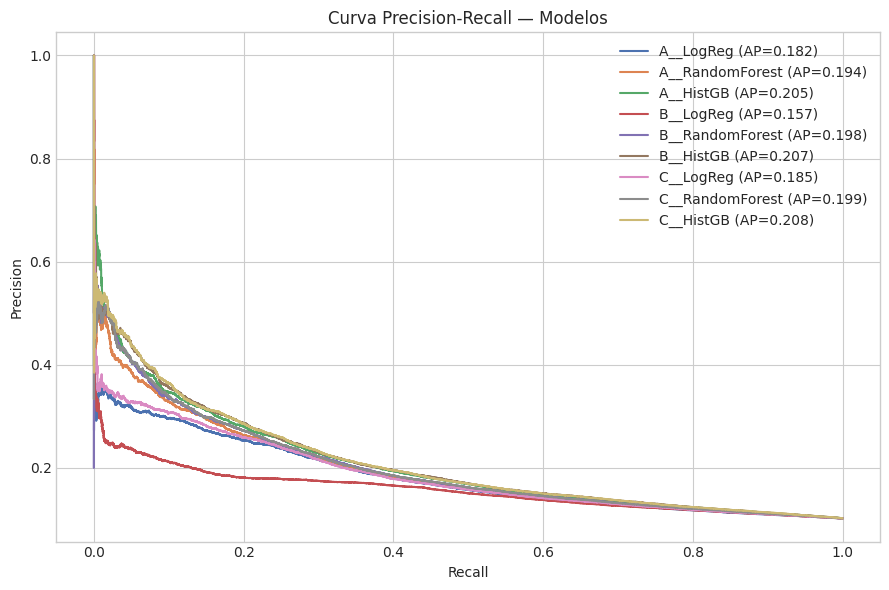

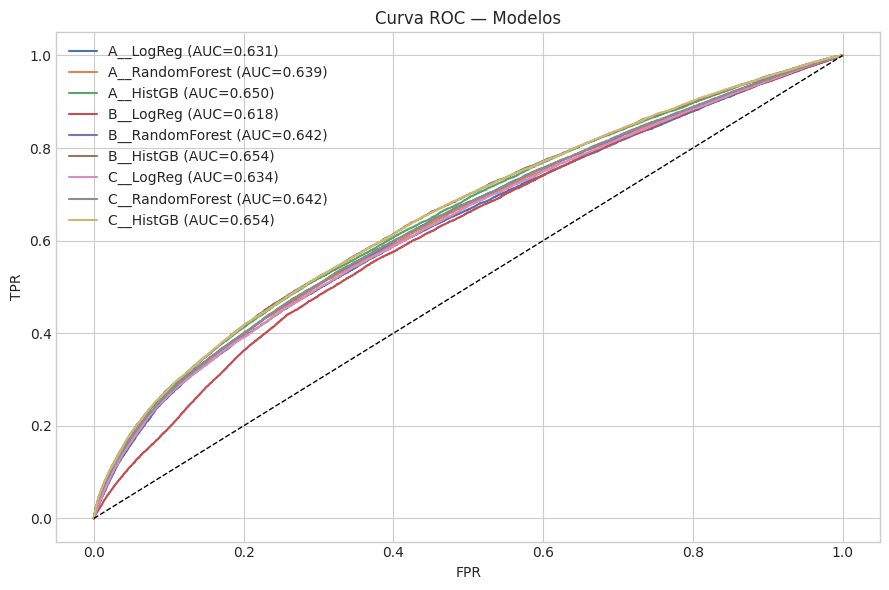

Salvos:
- ../results/figures/03_pr_curve_models.png
- ../results/figures/03_roc_curve_models.png


In [14]:
# PR Curve
plt.figure(figsize=(9, 6))
for model_name, result in search_results.items():
    X_test_curve = apply_scenario(X_test, result["scenario"])
    y_prob = result["best_estimator"].predict_proba(X_test_curve)[:, 1]
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    ap = average_precision_score(y_test, y_prob)
    plt.plot(recall, precision, label=f"{model_name} (AP={ap:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curva Precision-Recall — Modelos")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "03_pr_curve_models.png", dpi=150)
plt.show()

# ROC Curve
plt.figure(figsize=(9, 6))
for model_name, result in search_results.items():
    X_test_curve = apply_scenario(X_test, result["scenario"])
    y_prob = result["best_estimator"].predict_proba(X_test_curve)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{model_name} (AUC={auc:.3f})")

plt.plot([0, 1], [0, 1], "k--", linewidth=1)
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("Curva ROC — Modelos")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "03_roc_curve_models.png", dpi=150)
plt.show()

print("Salvos:")
print("-", FIGURES_DIR / "03_pr_curve_models.png")
print("-", FIGURES_DIR / "03_roc_curve_models.png")


### Comentário de leitura: PR e ROC
- A curva PR é central em base desbalanceada, pois evidencia o comportamento da classe positiva.
- ROC-AUC complementa a análise de discriminação global, mas não substitui a leitura de recall/precisão operacional.


## 12. Matrizes de confusão do melhor modelo


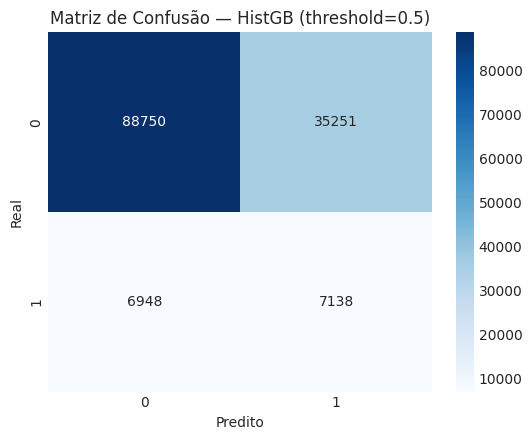

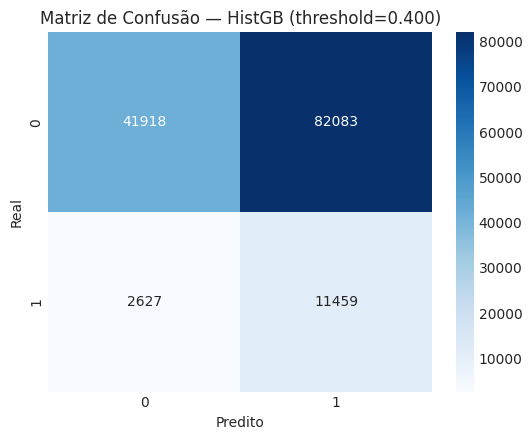

Salvos:
- ../results/figures/03_confusion_matrix_best_default.png
- ../results/figures/03_confusion_matrix_best_tuned.png


In [15]:
def plot_confusion(y_true, y_prob, threshold, title, output_file):
    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(5.5, 4.5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(title)
    plt.xlabel("Predito")
    plt.ylabel("Real")
    plt.tight_layout()
    plt.savefig(output_file, dpi=150)
    plt.show()

plot_confusion(
    y_test,
    y_test_prob_best,
    threshold=0.5,
    title=f"Matriz de Confusão — {best_model_name} (threshold=0.5)",
    output_file=FIGURES_DIR / "03_confusion_matrix_best_default.png",
)

plot_confusion(
    y_test,
    y_test_prob_best,
    threshold=selected_threshold,
    title=f"Matriz de Confusão — {best_model_name} (threshold={selected_threshold:.3f})",
    output_file=FIGURES_DIR / "03_confusion_matrix_best_tuned.png",
)

print("Salvos:")
print("-", FIGURES_DIR / "03_confusion_matrix_best_default.png")
print("-", FIGURES_DIR / "03_confusion_matrix_best_tuned.png")


### Comentário de leitura: matrizes de confusão
- A matriz com threshold ajustado deve mostrar mais verdadeiros positivos e também mais falsos positivos.
- Esse comportamento confirma o objetivo da calibração: reduzir falso negativo em cenário de triagem.


## 13. Handoff para 04_interpretability

Mantém em memória:
- `best_model_name`
- `best_model`
- `rf_feature_ranking`


### Limitações e uso responsável
- O modelo é suporte à triagem e não substitui decisão clínica.
- Há risco de viés por cobertura, preenchimento e qualidade dos registros SINASC.
- Resultados devem ser interpretados junto ao contexto assistencial local.


## 14. Importância das variáveis

Para cada tipo de modelo, seleciona o melhor cenário (maior CV F2) e extrai importância das features:
- **LogReg**: valor absoluto dos coeficientes (dados já escalados → magnitudes comparáveis)
- **RandomForest**: `feature_importances_` (mean decrease in impurity)
- **HistGB**: permutation importance (ROC-AUC) em subsample de 5 000 linhas — HistGradientBoostingClassifier não expõe `feature_importances_` diretamente no sklearn ≥ 1.3

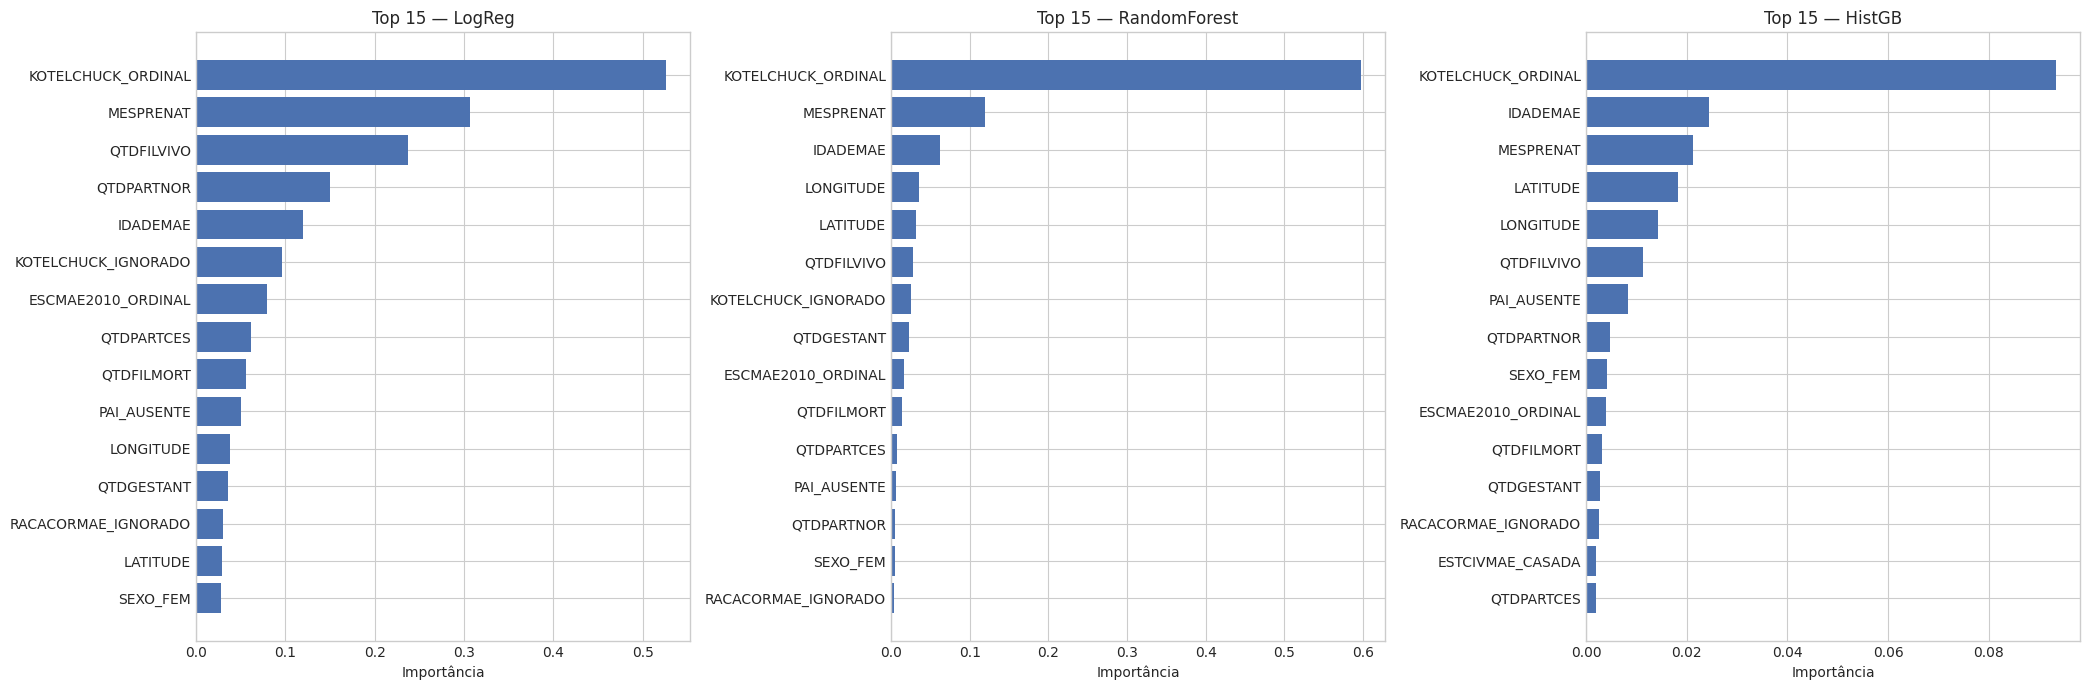


LogReg


,feature,importance
0,KOTELCHUCK_ORDINAL,0.526405
1,MESPRENAT,0.306033
2,QTDFILVIVO,0.237426
3,QTDPARTNOR,0.150214
4,IDADEMAE,0.119832
5,KOTELCHUCK_IGNORADO,0.095812
6,ESCMAE2010_ORDINAL,0.079868
7,QTDPARTCES,0.061936
8,QTDFILMORT,0.056329
9,PAI_AUSENTE,0.050227



RandomForest


,feature,importance
0,KOTELCHUCK_ORDINAL,0.597853
1,MESPRENAT,0.119694
2,IDADEMAE,0.061667
3,LONGITUDE,0.035038
4,LATITUDE,0.032122
5,QTDFILVIVO,0.027837
6,KOTELCHUCK_IGNORADO,0.025203
7,QTDGESTANT,0.023254
8,ESCMAE2010_ORDINAL,0.016969
9,QTDFILMORT,0.014179



HistGB


,feature,importance
0,KOTELCHUCK_ORDINAL,0.093412
1,IDADEMAE,0.024521
2,MESPRENAT,0.021227
3,LATITUDE,0.018297
4,LONGITUDE,0.014338
5,QTDFILVIVO,0.011366
6,PAI_AUSENTE,0.008306
7,QTDPARTNOR,0.004851
8,SEXO_FEM,0.004098
9,ESCMAE2010_ORDINAL,0.003915


In [16]:
PERM_SAMPLE = 5_000  # subsample for permutation importance (HistGB only)


def _extract_importances(model, feature_names, model_type, X_sample=None, y_sample=None):
    if model_type == "LogReg":
        scores = np.abs(model.coef_[0])
    elif model_type == "HistGB":
        # HistGradientBoostingClassifier does not expose feature_importances_;
        # permutation importance on a subsample is the recommended alternative.
        perm = permutation_importance(
            model, X_sample, y_sample,
            n_repeats=10, scoring="roc_auc",
            random_state=RANDOM_STATE, n_jobs=N_JOBS,
        )
        scores = perm.importances_mean
    else:
        scores = model.feature_importances_
    return (
        pd.DataFrame({"feature": feature_names, "importance": scores})
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
    )


importance_tables = {}
for model_type in ["LogReg", "RandomForest", "HistGB"]:
    candidates = {k: v for k, v in search_results.items() if v["model"] == model_type}
    if not candidates:
        continue
    best_key = max(candidates, key=lambda k: candidates[k]["cv_f2_mean"])
    result = candidates[best_key]
    X_scenario = apply_scenario(X_train, result["scenario"])
    feature_names = X_scenario.columns.tolist()

    X_sample, y_sample = None, None
    if model_type == "HistGB":
        rng = np.random.default_rng(RANDOM_STATE)
        idx = rng.choice(len(X_scenario), size=min(PERM_SAMPLE, len(X_scenario)), replace=False)
        X_sample = X_scenario.iloc[idx]
        y_sample = y_train.iloc[idx]

    importance_tables[model_type] = _extract_importances(
        result["best_estimator"], feature_names, model_type, X_sample, y_sample
    )

# Handoff para notebook 04
rf_feature_ranking = importance_tables.get("RandomForest")

# Visualização
n_models = len(importance_tables)
fig, axes = plt.subplots(1, n_models, figsize=(7 * n_models, 7))
if n_models == 1:
    axes = [axes]

for ax, (model_type, df) in zip(axes, importance_tables.items()):
    top = df.head(15)
    ax.barh(top["feature"][::-1], top["importance"][::-1])
    ax.set_title(f"Top 15 — {model_type}")
    ax.set_xlabel("Importância")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "03_feature_importance.png", dpi=150)
plt.show()

for model_type, df in importance_tables.items():
    print(f"\n{model_type}")
    display(df.head(15))